In [ ]:
import numpy as np
import pandas 
import matplotlib as plt
import scipy 
import mne

In [ ]:
%pip install mne

In [ ]:
import mne
from mne.datasets import eegbci

print("Ricerca / Download del tracciato in corso...")
percorsi_file = eegbci.load_data(subjects=1, runs=[2])

percorso_edf = percorsi_file[0]
raw = mne.io.read_raw_edf(percorso_edf, preload=True)

print("\n--- INFORMAZIONI SUL TRACCIATO EEG ---")
print(raw.info)

 

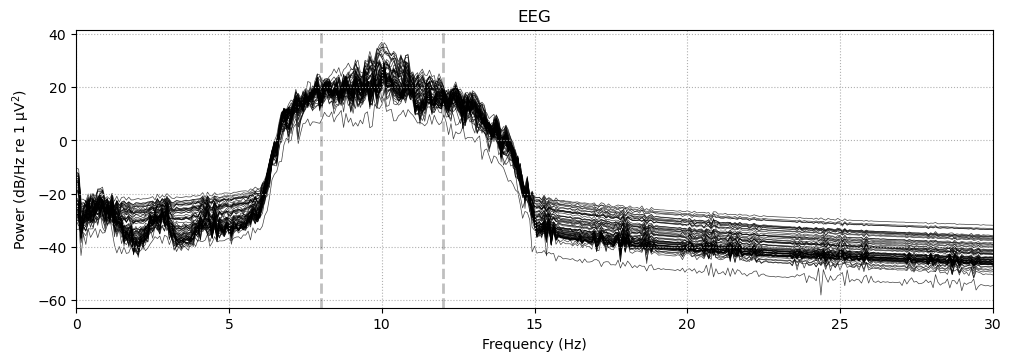

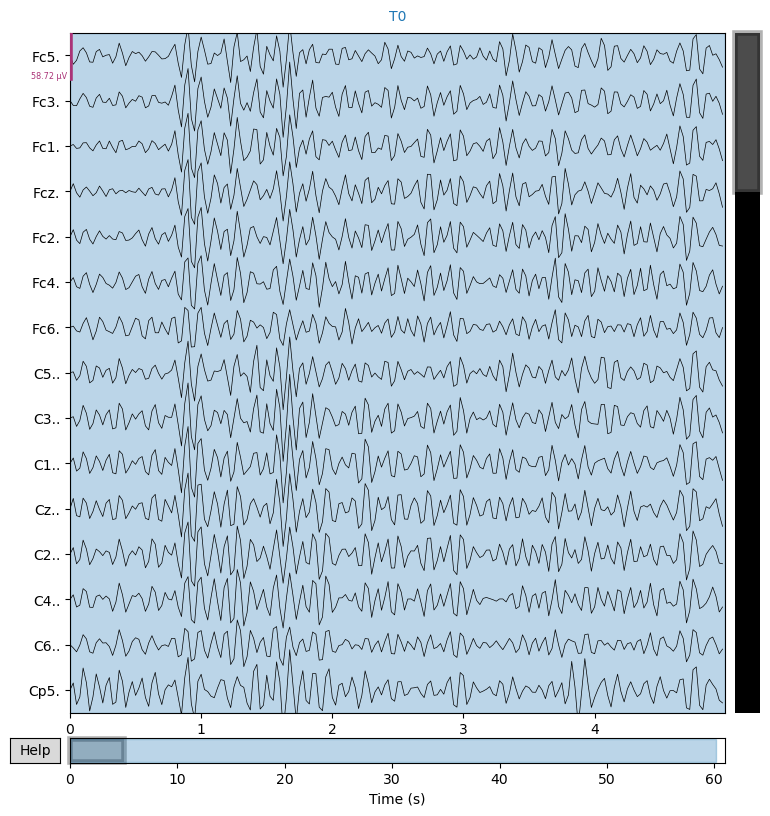

In [7]:
# Creiamo il grafico guardando 5 secondi di registrazione su 15 elettrodi
finestra_grafica = raw.plot(duration=5.0, n_channels=15, scalings='auto')


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 265 samples (1.656 s)



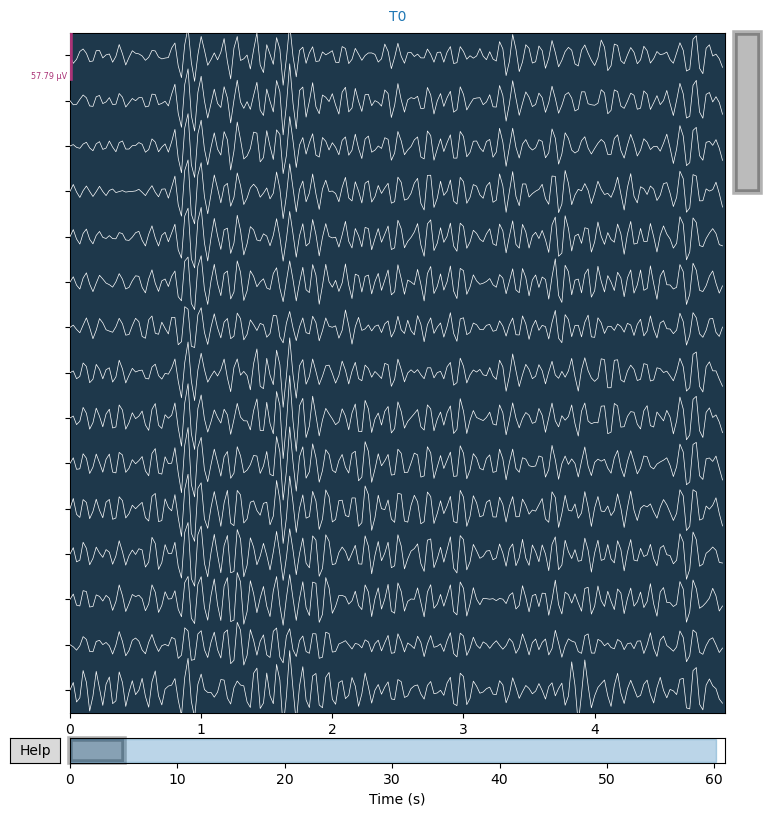

In [8]:
# 1. Filtriamo il segnale: teniamo isolata solo la "Banda Alfa" (8-12 Hz)
raw.filter(l_freq=8.0, h_freq=12.0)

# 2. Ridisegniamo le onde per vedere la differenza!
finestra_grafica_filtrata = raw.plot(
    duration=5.0, 
    n_channels=15, 
    scalings='auto',
    bgcolor='#1e1e1e',          
    color=dict(eeg='white')     
)


Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_24376\3267201604.py:4: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  spettro.plot()
c:\Users\Utente\anaconda3\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


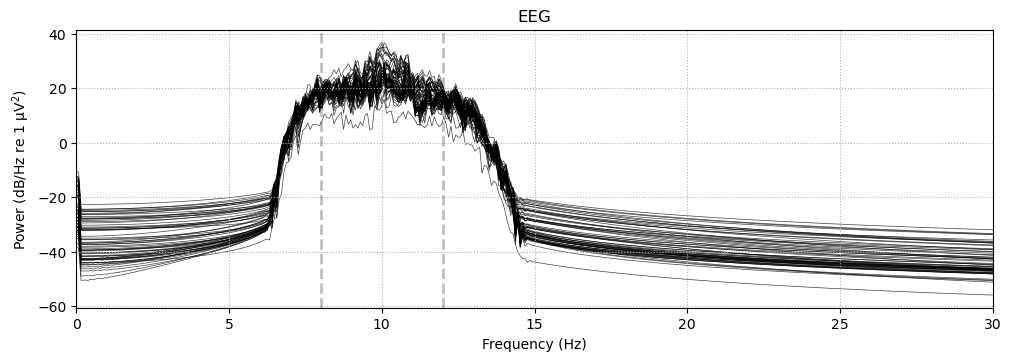

In [9]:
# 1. Calcoliamo la potenza massimo fino a 30Hz per zoomare 
spettro = raw.compute_psd(fmax=30.0)

spettro.plot()
